# LVS-VAE Head Performance Analysis

Use this notebook to evaluate LVS-VAE checkpoint performance for the outcome value head and placing-survival head. Ensemble and live PPO gate analysis are intentionally excluded.

### Setup and Dataset Load

In [17]:
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path("../..").resolve()
DATASET_DIR = PROJECT_ROOT / "VAE_DATA" / "full_20k_40_40_20"

NPZ_PATH = DATASET_DIR / "states_labels.npz"
DATASET_CSV_PATH = DATASET_DIR / "dataset.csv"
METADATA_CSV_PATH = DATASET_DIR / "metadata.csv"
DATASET_PARQUET_PATH = DATASET_DIR / "dataset.parquet"
METADATA_PARQUET_PATH = DATASET_DIR / "metadata.parquet"

DATASET_DIR

WindowsPath('C:/Users/chris/OneDrive/Documents/GitHub/TNG_Falcon/VAE_DATA/full_20k_40_40_20')

In [18]:
with np.load(NPZ_PATH, allow_pickle=False) as npz_data:
    print("NPZ keys:", npz_data.files)
    states = npz_data["states"]
    labels = npz_data["labels"]
    state_columns = npz_data["state_columns"] if "state_columns" in npz_data.files else np.array([])

npz_summary_df = pd.DataFrame(
    [
        {"array": "states", "shape": states.shape, "dtype": states.dtype},
        {"array": "labels", "shape": labels.shape, "dtype": labels.dtype},
        {"array": "state_columns", "shape": state_columns.shape, "dtype": state_columns.dtype},
    ]
)
npz_summary_df

NPZ keys: ['states', 'labels', 'state_columns']


,array,shape,dtype
0,states,"(20000, 25)",int8
1,labels,"(20000,)",float32
2,state_columns,"(25,)",<U17


In [19]:
state_columns = [str(column) for column in state_columns]
npz_dataset_df = pd.DataFrame(states, columns=state_columns)
npz_dataset_df["value_label"] = labels
npz_dataset_df.head()

,cell_00,cell_01,cell_02,cell_03,cell_04,cell_05,cell_06,cell_07,cell_08,cell_09,...,cell_16,cell_17,cell_18,cell_19,cell_20,cell_21,cell_22,goats_eaten_state,phase_state,value_label
0,2,0,0,2,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.0
1,2,0,0,2,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1.0
2,2,0,2,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,1.0
3,0,0,2,0,2,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,1.0
4,1,2,0,0,2,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,1.0


In [20]:
def load_table(parquet_path, csv_path):
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    if csv_path.exists():
        return pd.read_csv(csv_path)
    raise FileNotFoundError(f"Missing table: {parquet_path} or {csv_path}")


dataset_df = load_table(DATASET_PARQUET_PATH, DATASET_CSV_PATH)
metadata_df = load_table(METADATA_PARQUET_PATH, METADATA_CSV_PATH)

pd.DataFrame(
    [
        {"dataframe": "dataset_df", "rows": len(dataset_df), "columns": dataset_df.shape[1]},
        {"dataframe": "metadata_df", "rows": len(metadata_df), "columns": metadata_df.shape[1]},
    ]
)

,dataframe,rows,columns
0,dataset_df,20000,26
1,metadata_df,20000,12


## Head Analysis

Evaluate LVS-VAE checkpoints and compare the outcome value head separately from the placing-survival head.

Configure one or more saved LVS-VAE checkpoints below. This evaluates each model against the currently loaded NPZ dataset.

In [21]:
import sys
import torch
from torch.utils.data import DataLoader, TensorDataset

vae_dir = PROJECT_ROOT / "VAE"
if str(vae_dir) not in sys.path:
    sys.path.append(str(vae_dir))

from LVS_VAE import LVSVAE


def load_lvs_vae_checkpoint(checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    config = checkpoint.get("config", {})

    model = LVSVAE(
        input_dim=int(config.get("input_dim", 25)),
        latent_dim=int(config.get("latent_dim", 8)),
        hidden_dims=tuple(config.get("hidden_dims", (64, 64))),
        value_hidden_dim=int(config.get("value_hidden_dim", 32)),
    ).to(device)
    model.load_state_dict(checkpoint["model_state_dict"], strict=False)
    model.eval()
    return model, checkpoint, config


def find_training_metrics_csv(checkpoint_path, config):
    run_name = config.get("run_name")
    if run_name:
        metrics_path = checkpoint_path.parent / f"{run_name}_metrics.csv"
        if metrics_path.exists():
            return metrics_path

    metrics_files = sorted(checkpoint_path.parent.glob("*_metrics.csv"))
    return metrics_files[0] if metrics_files else None


def load_training_time_summary(checkpoint_path, config):
    metrics_path = find_training_metrics_csv(checkpoint_path, config)
    if metrics_path is None:
        return {"metrics_path": None, "run_elapsed_time": None}

    metrics_df = pd.read_csv(metrics_path)
    if metrics_df.empty or "elapsed_time" not in metrics_df.columns:
        return {"metrics_path": str(metrics_path), "run_elapsed_time": None}

    final_row = metrics_df.iloc[-1]
    return {
        "metrics_path": str(metrics_path),
        "run_elapsed_time": final_row.get("elapsed_time"),
    }

In [22]:
MODEL_CHECKPOINTS = {
    "end_20k_joint_ps": PROJECT_ROOT / r"artifacts\lvs_vae_ps\end_20k_joint_ps_v1\end_20k_joint_ps_v1_best_model.pt",
    "end_40k_joint_ps": PROJECT_ROOT / r"artifacts\lvs_vae_ps\end_40k_joint_ps_v1\end_40k_joint_ps_v1_best_model.pt",
    "full_20k_joint_ps": PROJECT_ROOT / r"artifacts\lvs_vae_ps\full_20k_joint_ps_v1\full_20k_joint_ps_v1_best_model.pt",
    "full_40k_joint_ps": PROJECT_ROOT / r"artifacts\lvs_vae_ps\full_40k_joint_ps_v1\full_40k_joint_ps_v1_best_model.pt",
    "full_40k_frozen" : PROJECT_ROOT / r"artifacts\lvs_vae\full_40k_frozen_lvsvae_heads_v1\full_40k_frozen_lvsvae_heads_v1_best_model.pt"
}

EVALUATION_DEVICE = "cpu"
EVALUATION_BATCH_SIZE = 512

device = torch.device(EVALUATION_DEVICE)

checkpoint_files_df = pd.DataFrame(
    [
        {
            "model_name": name,
            "path": str(path),
            "exists": path.exists(),
        }
        for name, path in MODEL_CHECKPOINTS.items()
    ]
)
checkpoint_files_df

,model_name,path,exists
0,end_20k_joint_ps,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,True
1,end_40k_joint_ps,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,True
2,full_20k_joint_ps,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,True
3,full_40k_joint_ps,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,True
4,full_40k_frozen,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,True


### Checkpoint Head Comparison

Evaluate outcome_value and placing_survival metrics separately for each checkpoint. Older or reconstruction-only checkpoints may include untrained head weights, so use them as baselines rather than final head-quality estimates.

In [23]:
def evaluate_checkpoint_heads(model, states_array, labels_array, device):
    states_tensor = torch.as_tensor(states_array, dtype=torch.float32)
    labels_tensor = torch.as_tensor(labels_array, dtype=torch.float32)
    phase_tensor = states_tensor[:, 24]
    placing_mask = phase_tensor == 0
    survival_labels = (labels_tensor > 0.0).float()

    loader = DataLoader(
        TensorDataset(states_tensor, labels_tensor, survival_labels, placing_mask),
        batch_size=EVALUATION_BATCH_SIZE,
        shuffle=False,
    )

    outcome_predictions = []
    outcome_targets = []
    survival_predictions = []
    survival_targets = []

    with torch.no_grad():
        for batch_states, batch_labels, batch_survival_labels, batch_placing_mask in loader:
            batch_states = batch_states.to(device)
            batch_labels = batch_labels.to(device)
            batch_survival_labels = batch_survival_labels.to(device)
            batch_placing_mask = batch_placing_mask.to(device)

            outcome_predictions.append(model.predict_value(batch_states).detach().cpu().view(-1))
            outcome_targets.append(batch_labels.detach().cpu().view(-1))

            if batch_placing_mask.any():
                placing_states = batch_states[batch_placing_mask]
                placing_targets = batch_survival_labels[batch_placing_mask]
                survival_predictions.append(
                    model.predict_placing_survival(placing_states).detach().cpu().view(-1)
                )
                survival_targets.append(placing_targets.detach().cpu().view(-1))

    results = {}
    predictions = torch.cat(outcome_predictions)
    targets = torch.cat(outcome_targets)
    errors = predictions - targets
    mse = torch.mean(errors.pow(2))
    results["outcome_value"] = {
        "rows": int(len(targets)),
        "mse": float(mse.item()),
        "rmse": float(torch.sqrt(mse).item()),
        "mae": float(torch.mean(torch.abs(errors)).item()),
        "prediction_mean": float(predictions.mean().item()),
        "prediction_std": float(predictions.std(unbiased=False).item()),
        "target_mean": float(targets.mean().item()),
        "predictions": predictions.numpy(),
        "targets": targets.numpy(),
    }

    if survival_predictions:
        predictions = torch.cat(survival_predictions)
        targets = torch.cat(survival_targets)
        errors = predictions - targets
        mse = torch.mean(errors.pow(2))
        results["placing_survival"] = {
            "rows": int(len(targets)),
            "mse": float(mse.item()),
            "rmse": float(torch.sqrt(mse).item()),
            "mae": float(torch.mean(torch.abs(errors)).item()),
            "prediction_mean": float(predictions.mean().item()),
            "prediction_std": float(predictions.std(unbiased=False).item()),
            "target_mean": float(targets.mean().item()),
            "predictions": predictions.numpy(),
            "targets": targets.numpy(),
        }

    return results


head_evaluation_rows = []
head_prediction_frames = []

for model_name, checkpoint_path in MODEL_CHECKPOINTS.items():
    if not checkpoint_path.exists():
        continue

    model, checkpoint, config = load_lvs_vae_checkpoint(checkpoint_path, device)
    state_dict = checkpoint.get("model_state_dict", {})
    has_trained_survival_head = any(
        key.startswith("placing_survival_head.") for key in state_dict
    )
    training_time = load_training_time_summary(checkpoint_path, config)
    head_results = evaluate_checkpoint_heads(model, states, labels, device)

    for head_name, result in head_results.items():
        head_evaluation_rows.append(
            {
                "model_name": model_name,
                "head_name": head_name,
                "has_trained_survival_head": has_trained_survival_head,
                "checkpoint_path": str(checkpoint_path),
                "trained_run_name": config.get("run_name"),
                "trained_data_path": config.get("data_path"),
                "training_metrics_path": training_time["metrics_path"],
                "run_elapsed_time": training_time["run_elapsed_time"],
                "rows": result["rows"],
                "mse": result["mse"],
                "rmse": result["rmse"],
                "mae": result["mae"],
                "prediction_mean": result["prediction_mean"],
                "prediction_std": result["prediction_std"],
                "target_mean": result["target_mean"],
            }
        )
        head_prediction_frames.append(
            pd.DataFrame(
                {
                    "model_name": model_name,
                    "head_name": head_name,
                    "has_trained_survival_head": has_trained_survival_head,
                    "target_label": result["targets"],
                    "prediction": result["predictions"],
                    "error": result["predictions"] - result["targets"],
                    "abs_error": np.abs(result["predictions"] - result["targets"]),
                }
            )
        )

head_evaluation_df = pd.DataFrame(head_evaluation_rows)
if not head_evaluation_df.empty:
    head_evaluation_df = head_evaluation_df.sort_values(
        ["head_name", "rmse"],
        ignore_index=True,
    )

head_predictions_df = (
    pd.concat(head_prediction_frames, ignore_index=True)
    if head_prediction_frames
    else pd.DataFrame()
)

head_evaluation_df

,model_name,head_name,has_trained_survival_head,checkpoint_path,trained_run_name,trained_data_path,training_metrics_path,run_elapsed_time,rows,mse,rmse,mae,prediction_mean,prediction_std,target_mean
0,full_20k_joint_ps,outcome_value,True,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,full_20k_joint_ps_v1,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,00:02:26,20000,0.091304,0.302166,0.222709,0.509621,0.331533,0.500000
1,full_40k_joint_ps,outcome_value,True,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,full_40k_joint_ps_v1,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,00:04:50,20000,0.094750,0.307815,0.226127,0.511184,0.337391,0.500000
2,full_40k_frozen,outcome_value,True,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,full_40k_frozen_lvsvae_heads_v1,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,00:02:58,20000,0.136993,0.370126,0.313549,0.503447,0.256208,0.500000
3,end_40k_joint_ps,outcome_value,True,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,end_40k_joint_ps_v1,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,00:04:21,20000,0.177444,0.421241,0.255434,0.465303,0.407124,0.500000
4,end_20k_joint_ps,outcome_value,True,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,end_20k_joint_ps_v1,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,00:02:21,20000,0.191465,0.437567,0.272866,0.493202,0.400082,0.500000
5,full_20k_joint_ps,placing_survival,True,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,full_20k_joint_ps_v1,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,00:02:26,10110,0.115928,0.340482,0.228534,0.442280,0.366145,0.439763
6,full_40k_joint_ps,placing_survival,True,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,full_40k_joint_ps_v1,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,00:04:50,10110,0.124592,0.352976,0.242018,0.434583,0.358182,0.439763
7,full_40k_frozen,placing_survival,True,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,full_40k_frozen_lvsvae_heads_v1,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,00:02:58,10110,0.188658,0.434348,0.378281,0.434463,0.236816,0.439763
8,end_40k_joint_ps,placing_survival,True,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,end_40k_joint_ps_v1,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,00:04:21,10110,0.282349,0.531366,0.296681,0.389123,0.472626,0.439763
9,end_20k_joint_ps,placing_survival,True,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,end_20k_joint_ps_v1,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,00:02:21,10110,0.308094,0.555062,0.331310,0.451600,0.473752,0.439763


In [24]:
if not head_predictions_df.empty:
    head_per_label_df = (
        head_predictions_df
        .groupby(["model_name", "head_name", "target_label"])
        .agg(
            rows=("prediction", "size"),
            pred_mean=("prediction", "mean"),
            pred_std=("prediction", "std"),
            mae=("abs_error", "mean"),
            mse=("error", lambda values: np.mean(np.square(values))),
        )
        .reset_index()
    )
    head_per_label_df["rmse"] = np.sqrt(head_per_label_df["mse"])
else:
    head_per_label_df = pd.DataFrame()

head_per_label_df

,model_name,head_name,target_label,rows,pred_mean,pred_std,mae,mse,rmse
0,end_20k_joint_ps,outcome_value,0.0,8000,0.273094,0.396990,0.273094,0.232162,0.481832
1,end_20k_joint_ps,outcome_value,0.5,4000,0.530399,0.276276,0.207562,0.077234,0.277910
2,end_20k_joint_ps,outcome_value,1.0,8000,0.694712,0.338670,0.305288,0.207884,0.455943
3,end_20k_joint_ps,placing_survival,0.0,5664,0.306251,0.436553,0.306251,0.284335,0.533231
4,end_20k_joint_ps,placing_survival,1.0,4446,0.636767,0.454388,0.363233,0.338361,0.581688
5,end_40k_joint_ps,outcome_value,0.0,8000,0.207432,0.360943,0.207432,0.173291,0.416283
6,end_40k_joint_ps,outcome_value,0.5,4000,0.549243,0.286670,0.224716,0.084584,0.290833
7,end_40k_joint_ps,outcome_value,1.0,8000,0.681205,0.355545,0.318795,0.228027,0.477522
8,end_40k_joint_ps,placing_survival,0.0,5664,0.219586,0.399180,0.219586,0.207535,0.455560
9,end_40k_joint_ps,placing_survival,1.0,4446,0.605105,0.470922,0.394895,0.377660,0.614541


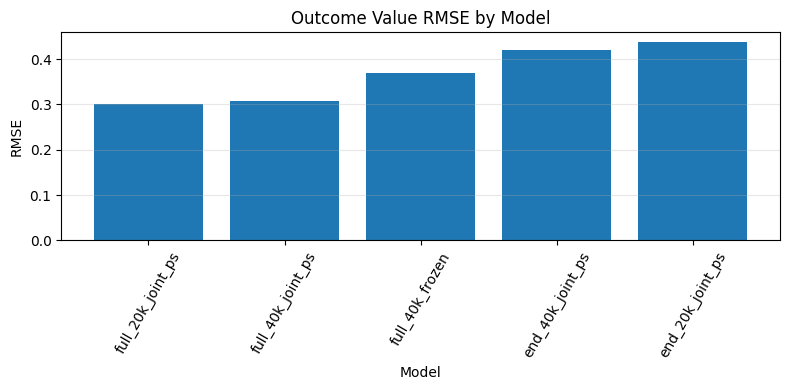

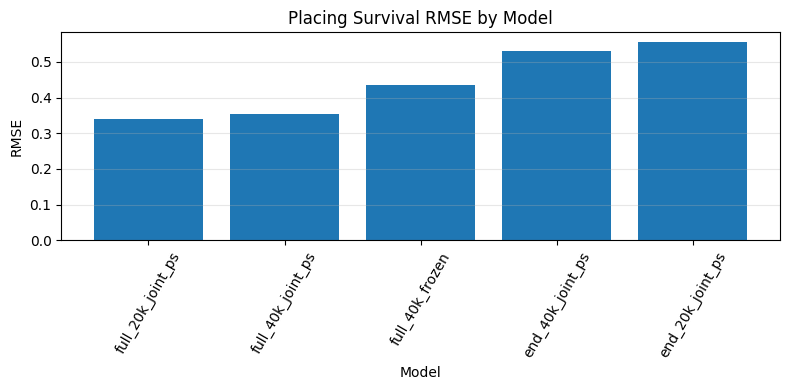

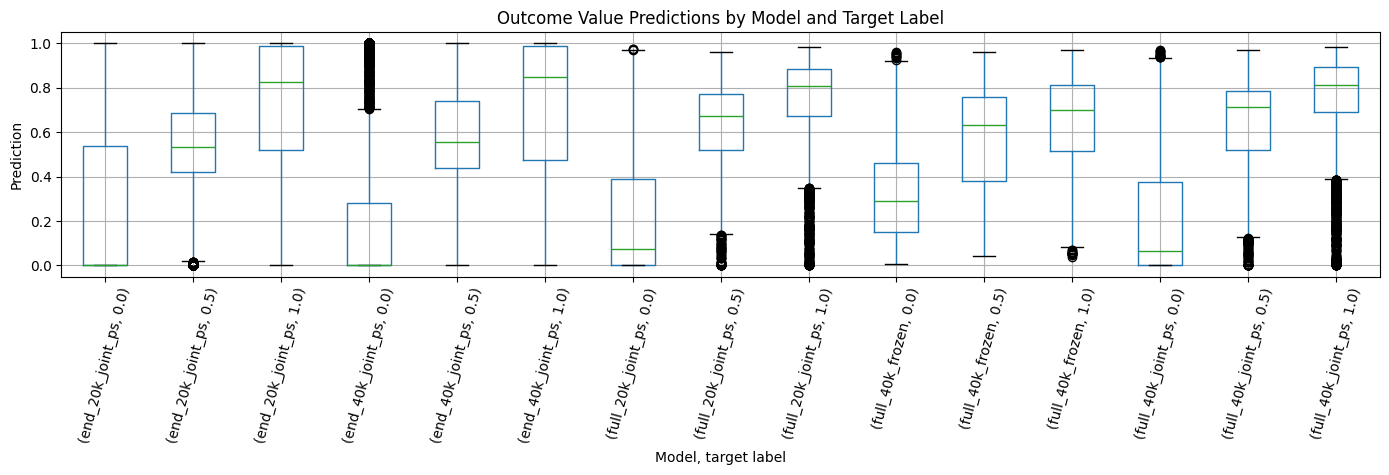

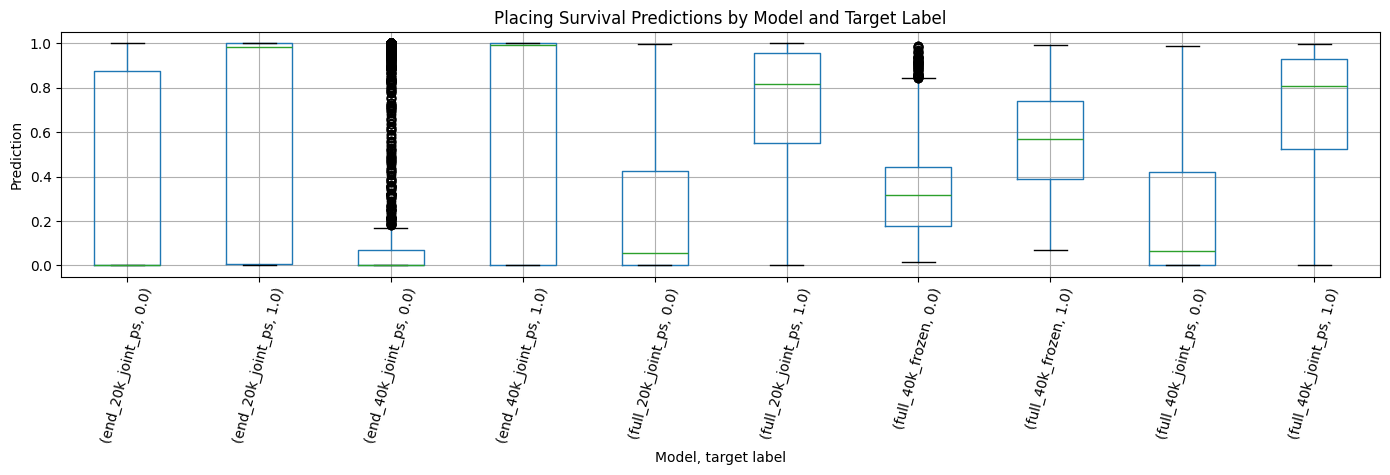

In [25]:
if head_evaluation_df.empty and head_predictions_df.empty:
    print("No checkpoint head results found. Update MODEL_CHECKPOINTS and rerun this section.")
else:
    try:
        import matplotlib.pyplot as plt

        if not head_evaluation_df.empty:
            for head_name, head_df in head_evaluation_df.groupby("head_name"):
                plot_df = head_df.sort_values("rmse")
                fig_width = max(8, len(plot_df) * 0.75)
                fig, ax = plt.subplots(figsize=(fig_width, 4))
                ax.bar(plot_df["model_name"], plot_df["rmse"])
                ax.set_title(f"{head_name.replace('_', ' ').title()} RMSE by Model")
                ax.set_xlabel("Model")
                ax.set_ylabel("RMSE")
                ax.tick_params(axis="x", rotation=60)
                ax.grid(axis="y", alpha=0.3)
                fig.tight_layout()
                plt.show()

        if not head_predictions_df.empty:
            for head_name, head_df in head_predictions_df.groupby("head_name"):
                ax = head_df.boxplot(
                    column="prediction",
                    by=["model_name", "target_label"],
                    figsize=(14, 5),
                    rot=75,
                )
                ax.set_title(f"{head_name.replace('_', ' ').title()} Predictions by Model and Target Label")
                ax.set_xlabel("Model, target label")
                ax.set_ylabel("Prediction")
                plt.suptitle("")
                plt.tight_layout()
                plt.show()
    except ImportError:
        print("matplotlib is not installed; skipping head plots.")